# TRABALHO FINAL — Volis Case Study

Nome completo do(a) estudante: (Se for trabalho em grupo, liste todos os nomes)

Dataset: volis_dataset.csv

Entrega: este notebook (.ipynb) devidamente preenchido e reprodutível

## 0) Importações e configurações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos (use apenas os que precisar, conforme o desafio escolhido)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)

# Para ter resultados reproduzíveis (mude apenas se quiser)
RANDOM_STATE = 42

In [2]:
# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 8]

## 1) Carregamento dos dados

In [3]:
# Ajuste o caminho do ficheiro se necessário
DATA_PATH = "volis_dataset.csv"

df = pd.read_csv(DATA_PATH)

## 2) Visão geral do dataset

In [4]:
print("Dimensão (linhas, colunas):", df.shape)
display(df.sample(5, random_state=RANDOM_STATE))

print("\nTipos de dados:")
print(df.dtypes)

print("\nResumo estatístico (numéricas):")
display(df.describe())

Dimensão (linhas, colunas): (977, 19)


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
199,Ouachita Baptist University,True,910.0,773.0,450.0,31.0,73.0,1310.0,61.0,6530.0,2800.0,500.0,1500.0,63.0,67.0,13.3,10.0,6413.0,65.0
542,Northwest Missouri State University,False,2729.0,2535.0,1257.0,8.0,29.0,4787.0,472.0,3735.0,3136.0,250.0,1630.0,62.0,65.0,21.7,23.0,5284.0,54.0
174,Cabrini College,True,599.0,494.0,224.0,8.0,28.0,1035.0,446.0,10518.0,6250.0,300.0,300.0,59.0,76.0,16.5,36.0,7117.0,71.0
764,Joan of Arc College,NaN,100000.0,1500.0,500.0,20.0,40.0,50000.0,1.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,100.0,NaN,60.0
66,Emily Dickinson College,False,2000.0,1500.0,500.0,20.0,40.0,2000.0,NaN,1000000.0,5000.0,600.0,1500.0,60.0,0.0,15.0,20.0,8000.0,60.0



Tipos de dados:
nm_college                             str
bl_private                          object
qt_applications_received           float64
qt_applications_accepted           float64
qt_students_enrolled               float64
qt_top_10_percent                  float64
qt_top_25_percent                  float64
qt_undergraduate_students          float64
qt_postgraduate_students           float64
vl_tuition_outstate                float64
vl_room_board                      float64
vl_books_cost                      float64
vl_personal_expenses               float64
pc_faculty_with_phd                float64
pc_faculty_with_terminal_degree    float64
vl_student_faculty_ratio           float64
pc_alumni_donors                   float64
vl_expenditure_per_student         float64
pc_graduation_rate                 float64
dtype: object

Resumo estatístico (numéricas):


,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
count,962.000000,955.000000,956.000000,956.000000,962.000000,961.000000,960.000000,959.000000,957.000000,958.00000,965.000000,956.000000,955.000000,960.000000,961.000000,955.000000,963.000000
mean,3407.768191,2049.859686,792.927824,26.457113,52.904366,3518.034339,810.072917,12379.983316,4504.491118,604.24739,1443.190674,70.331590,75.779058,14.305208,22.551509,12425.086911,64.241952
std,8420.796455,2706.765606,1158.893541,17.123183,19.420941,5124.628362,1754.771752,45322.758310,1813.501606,698.62322,1714.550823,15.950903,16.837190,4.592944,12.597689,55674.935543,16.579696
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.100000,0.000000,1.000000,0.000000
25%,880.500000,702.000000,278.000000,17.000000,40.000000,1100.000000,131.750000,7860.000000,3700.000000,500.00000,920.000000,60.000000,60.000000,12.100000,15.000000,7086.500000,56.000000
50%,2000.000000,1500.000000,500.000000,20.000000,49.000000,2000.000000,300.000000,10000.000000,4514.000000,570.00000,1400.000000,71.000000,77.000000,14.700000,20.000000,8000.000000,60.000000
75%,2967.750000,2037.000000,724.000000,32.000000,65.000000,3051.000000,765.250000,12035.000000,5000.000000,600.00000,1525.000000,83.000000,90.000000,15.625000,29.000000,10077.000000,75.000000
max,100000.000000,26330.000000,10000.000000,100.000000,100.000000,50000.000000,21836.000000,1000000.000000,50000.000000,10000.00000,30000.000000,103.000000,100.000000,100.000000,100.000000,1000000.000000,118.000000


## 3) Qualidade dos dados: missing values e duplicados

In [5]:
# Missing values por coluna
print("\nValores em falta:")
display(df.isnull().sum())

# Percentual de missing por coluna
print("\nPercentual de valores em falta:")
display(df.isnull().mean() * 100)

# Linhas duplicadas
print("\nLinhas duplicadas:")
print(df.duplicated().sum())


Valores em falta:


nm_college                          0
bl_private                         21
qt_applications_received           15
qt_applications_accepted           22
qt_students_enrolled               21
qt_top_10_percent                  21
qt_top_25_percent                  15
qt_undergraduate_students          16
qt_postgraduate_students           17
vl_tuition_outstate                18
vl_room_board                      20
vl_books_cost                      19
vl_personal_expenses               12
pc_faculty_with_phd                21
pc_faculty_with_terminal_degree    22
vl_student_faculty_ratio           17
pc_alumni_donors                   16
vl_expenditure_per_student         22
pc_graduation_rate                 14
dtype: int64


Percentual de valores em falta:


nm_college                         0.000000
bl_private                         2.149437
qt_applications_received           1.535312
qt_applications_accepted           2.251791
qt_students_enrolled               2.149437
qt_top_10_percent                  2.149437
qt_top_25_percent                  1.535312
qt_undergraduate_students          1.637666
qt_postgraduate_students           1.740020
vl_tuition_outstate                1.842375
vl_room_board                      2.047083
vl_books_cost                      1.944729
vl_personal_expenses               1.228250
pc_faculty_with_phd                2.149437
pc_faculty_with_terminal_degree    2.251791
vl_student_faculty_ratio           1.740020
pc_alumni_donors                   1.637666
vl_expenditure_per_student         2.251791
pc_graduation_rate                 1.432958
dtype: float64


Linhas duplicadas:
0


In [6]:
# Limpeza de dados
# ================

linhas_originais = df.shape[0]
print(f"N. linhas originais: {linhas_originais}")

# Como todos os valores em falta são inferiores a 5%, então vamos remover essas linhas
df_limpo = df.dropna()

linhas_depois = df_limpo.shape[0]
print(f"N. linhas após limpeza: {linhas_depois}")
print(f"Percentual a remover: {(1 - linhas_depois / linhas_originais):.0%}")

print("Percentagem muito elevada. Não remover. Necessário efetuar algumas correções em vez de eliminar linhas.")

N. linhas originais: 977
N. linhas após limpeza: 817
Percentual a remover: 16%
Percentagem muito elevada. Não remover. Necessário efetuar algumas correções em vez de eliminar linhas.


In [7]:
print(f"N. linhas originais: {linhas_originais}")

# Remover linhas cujo target é vazio/NaN
df = df.dropna(subset=["bl_private"])

print(f"N. linhas após limpeza: {df.shape[0]}")
print(f"Percentual total de linhas removidas: {(1 - df.shape[0] / linhas_originais):.0%}")

N. linhas originais: 977
N. linhas após limpeza: 956
Percentual total de linhas removidas: 2%


In [10]:
#Analisar colunas percentagem
colunas_percentagem = ['qt_top_10_percent','qt_top_25_percent','pc_faculty_with_phd','pc_faculty_with_terminal_degree','pc_alumni_donors','pc_graduation_rate']

for col in colunas_percentagem:
    if col in df.columns:
        mask = (df[col] < 0) | (df[col] > 100)
        
        if mask.any():
            print(f"Coluna: {col}")
            display(df[mask])

In [9]:
#Corrigir percentagem
df['pc_faculty_with_phd'] = df['pc_faculty_with_phd'].replace(103, 100)
#Eliminar linha percentagem
df = df[((df['pc_graduation_rate'] < 118) | (df['pc_graduation_rate'].isnull()))]

print(f"N. linhas após limpeza: {df.shape[0]}")
print(f"Percentual total de linhas removidas: {(1 - df.shape[0] / linhas_originais):.0%}")

N. linhas após limpeza: 955
Percentual total de linhas removidas: 2%


In [11]:
colunas_numericas = df.columns.tolist()
colunas_numericas.remove('nm_college')
colunas_numericas.remove('bl_private')

variancia_original = (df[colunas_numericas].quantile(0.75) - df[colunas_numericas].quantile(0.25)).sort_values(ascending=False)

print(variancia_original)

vl_tuition_outstate                4318.500
vl_expenditure_per_student         3105.000
qt_applications_received           2118.000
qt_undergraduate_students          2049.250
qt_applications_accepted           1356.250
vl_room_board                      1320.000
vl_personal_expenses                648.750
qt_postgraduate_students            645.000
qt_students_enrolled                458.500
vl_books_cost                       100.000
pc_faculty_with_terminal_degree      30.000
qt_top_25_percent                    26.000
pc_faculty_with_phd                  23.000
pc_graduation_rate                   19.000
qt_top_10_percent                    16.000
pc_alumni_donors                     14.000
vl_student_faculty_ratio              3.775
dtype: float64


In [12]:
# análise da assimetria
skewness_original = df[colunas_numericas].skew().sort_values(ascending=False)

display(skewness_original)

vl_tuition_outstate                30.030217
vl_expenditure_per_student         21.232003
vl_room_board                      16.390357
vl_books_cost                      15.622358
vl_personal_expenses               14.343935
qt_applications_received           10.078752
qt_postgraduate_students            7.080989
vl_student_faculty_ratio            6.890944
qt_students_enrolled                4.619816
qt_applications_accepted            4.131037
qt_undergraduate_students           3.891210
qt_top_10_percent                   1.778356
pc_alumni_donors                    1.532051
qt_top_25_percent                   0.520633
pc_graduation_rate                 -0.266722
pc_faculty_with_phd                -0.523348
pc_faculty_with_terminal_degree    -0.946611
dtype: float64

<Axes: >

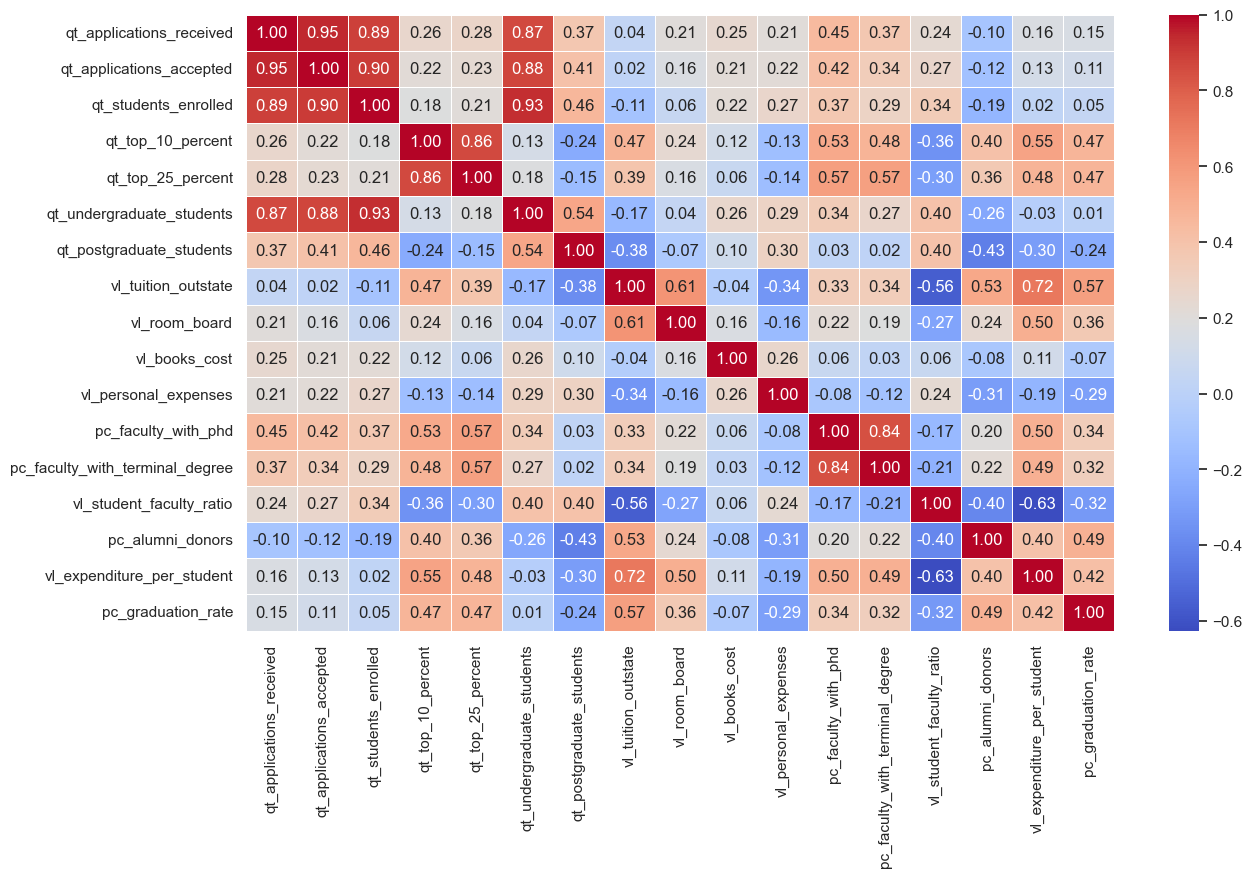

In [13]:
# assimetria muito elevada - pearson não serve
corr_spearman = df.corr(method='spearman', numeric_only=True)

# Gráfico: top correlações (ajuste como quiser)

plt.figure()
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [14]:
# Atributos Correlacionados

#colunas_corre = ['qt_applications_received','qt_applications_accepted','qt_students_enrolled','qt_undergraduate_students','qt_top_10_percent','qt_top_25_percent','pc_faculty_with_phd','pc_faculty_with_terminal_degree']
colunas_graduate = ['qt_applications_received','qt_applications_accepted','qt_students_enrolled','qt_undergraduate_students']
colunas_top_perc = ['qt_top_10_percent','qt_top_25_percent']
colunas_faculty = ['pc_faculty_with_phd','pc_faculty_with_terminal_degree']

In [17]:
# colunas com valores a 0/1
for col in colunas_numericas:
    print(f"Coluna: {col}: \n - Total valores inferiores a 1: {df[(df[col] <= 1)][col].count()} \n - Primeiro valor superior a 1 : {df[(df[col] > 1)][col].count()}")

Coluna: qt_applications_received: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 938
Coluna: qt_applications_accepted: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 929
Coluna: qt_students_enrolled: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 928
Coluna: qt_top_10_percent: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 929
Coluna: qt_top_25_percent: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 938
Coluna: qt_undergraduate_students: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 938
Coluna: qt_postgraduate_students: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 935
Coluna: vl_tuition_outstate: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 935
Coluna: vl_room_board: 
 - Total valores inferiores a 1: 0 
 - Primeiro valor superior a 1 : 934
Coluna: vl_books_cost: 
 - Total valores inferiores a 1: 0 
 

In [16]:
# Definir valores inferiores ou iguais a 1 como NaN
for col in colunas_numericas:
    df.loc[(df[col] <= 1), col] = np.nan

In [18]:
# colunas com outliers mais extremos
outliers_superiores = {}

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    #lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    max_value = df[col].max()
    #min_value = df[col].min()
    
    distance_upper = max(0, max_value - upper)
    #distance_lower = max(0, lower - min_value)
    
    outliers_superiores[col] = max(distance_upper, Q3)

pd.Series(outliers_superiores).sort_values(ascending=False)

vl_expenditure_per_student         985245.125
vl_tuition_outstate                981312.500
qt_applications_received            93832.000
qt_undergraduate_students           43748.625
vl_room_board                       43037.250
vl_personal_expenses                27521.250
qt_applications_accepted            22228.000
qt_postgraduate_students            20085.750
vl_books_cost                        9250.000
qt_students_enrolled                 8570.750
pc_faculty_with_terminal_degree        90.000
pc_faculty_with_phd                    83.000
vl_student_faculty_ratio               78.500
pc_graduation_rate                     75.000
qt_top_25_percent                      66.000
pc_alumni_donors                       50.000
qt_top_10_percent                      45.500
dtype: float64

<Axes: >

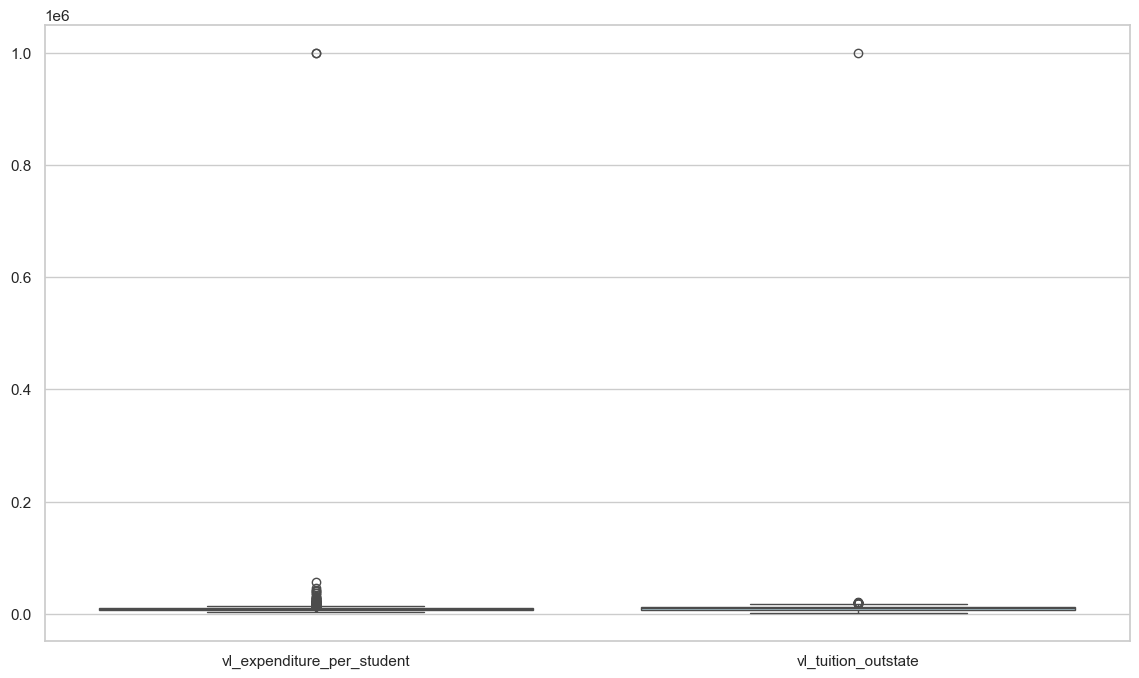

In [19]:
colunas_outliers = ['vl_expenditure_per_student', 'vl_tuition_outstate']

plt.figure()
sns.boxplot(data=df[colunas_outliers], color='lightblue')

In [20]:
for col in colunas_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    print(f"Coluna: {col}")
    display(df[df[col] > upper].sort_values(by=col,ascending=False).head(10))

Coluna: vl_expenditure_per_student


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
20,Mozart Academy,False,2000.0,1500.0,NaN,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,NaN,60.0,100.0,15.0,20.0,1000000.0,60.0
36,Alan Turing Center for Studies,False,2000.0,1500.0,NaN,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,1000000.0,60.0
269,Johns Hopkins University,True,8474.0,3446.0,911.0,75.0,94.0,3566.0,1569.0,18800.0,6740.0,500.0,1040.0,96.0,97.0,3.3,38.0,56233.0,90.0
94,Washington University,True,7654.0,5259.0,1254.0,62.0,93.0,4879.0,1274.0,18350.0,5775.0,768.0,1512.0,91.0,98.0,3.9,31.0,45702.0,90.0
820,Antioch University,True,713.0,661.0,252.0,25.0,44.0,712.0,23.0,15476.0,3336.0,400.0,1100.0,69.0,82.0,11.3,35.0,42926.0,48.0
512,Wake Forest University,True,5661.0,2392.0,903.0,75.0,88.0,3499.0,172.0,13850.0,4360.0,500.0,1250.0,95.0,97.0,4.3,37.0,41766.0,89.0
741,Yale University,True,10705.0,2453.0,1317.0,95.0,99.0,5217.0,83.0,19840.0,6510.0,630.0,2115.0,96.0,96.0,5.8,49.0,40386.0,99.0
739,Harvard University,True,13865.0,2165.0,1606.0,90.0,100.0,6862.0,320.0,18485.0,6410.0,500.0,1920.0,97.0,97.0,9.9,52.0,37219.0,100.0
450,University of Chicago,True,6348.0,2999.0,922.0,68.0,94.0,3340.0,39.0,18930.0,6380.0,500.0,1254.0,99.0,99.0,5.3,36.0,36854.0,90.0
924,Massachusetts Institute of Technology,True,6411.0,2140.0,1078.0,96.0,99.0,4481.0,28.0,20100.0,5975.0,725.0,1600.0,99.0,99.0,10.1,35.0,33541.0,94.0


Coluna: vl_tuition_outstate


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
66,Emily Dickinson College,False,2000.0,1500.0,500.0,20.0,40.0,2000.0,NaN,1000000.0,5000.0,600.0,1500.0,60.0,NaN,15.0,20.0,8000.0,60.0
253,Bennington College,True,519.0,327.0,114.0,25.0,53.0,457.0,2.0,21700.0,4100.0,600.0,500.0,35.0,59.0,10.1,33.0,16364.0,55.0
924,Massachusetts Institute of Technology,True,6411.0,2140.0,1078.0,96.0,99.0,4481.0,28.0,20100.0,5975.0,725.0,1600.0,99.0,99.0,10.1,35.0,33541.0,94.0
836,Gettysburg College,True,3596.0,2466.0,575.0,42.0,78.0,1944.0,46.0,19964.0,4328.0,500.0,500.0,94.0,95.0,12.1,32.0,14720.0,83.0
905,Reed College,True,1966.0,1436.0,327.0,47.0,80.0,1199.0,61.0,19960.0,5490.0,500.0,450.0,90.0,90.0,11.8,37.0,15886.0,68.0
763,Princeton University,True,13218.0,2042.0,1153.0,90.0,98.0,4540.0,146.0,19900.0,5910.0,675.0,1575.0,91.0,96.0,8.4,54.0,28320.0,99.0
741,Yale University,True,10705.0,2453.0,1317.0,95.0,99.0,5217.0,83.0,19840.0,6510.0,630.0,2115.0,96.0,96.0,5.8,49.0,40386.0,99.0
4,Amherst College,True,4302.0,992.0,418.0,83.0,96.0,1593.0,5.0,19760.0,5300.0,660.0,1598.0,93.0,98.0,8.4,63.0,21424.0,100.0
917,Hamilton College,True,3140.0,1783.0,454.0,40.0,82.0,1646.0,24.0,19700.0,5050.0,300.0,800.0,91.0,96.0,9.6,60.0,17761.0,91.0
502,Oberlin College,True,4778.0,2767.0,678.0,50.0,89.0,2587.0,120.0,19670.0,5820.0,575.0,1119.0,77.0,96.0,10.1,47.0,16593.0,83.0


In [21]:
#remover outliers impossíveis
df = df[
        ((df['vl_expenditure_per_student'] < 1000000) | (df['vl_expenditure_per_student'].isnull())) &
        ((df['vl_tuition_outstate'] < 1000000) | (df['vl_tuition_outstate'].isnull()))
    ]

print(f"N. linhas após limpeza: {df.shape[0]}")
print(f"Percentual total de linhas removidas: {(1 - df.shape[0] / linhas_originais):.0%}")

N. linhas após limpeza: 952
Percentual total de linhas removidas: 3%


<Axes: >

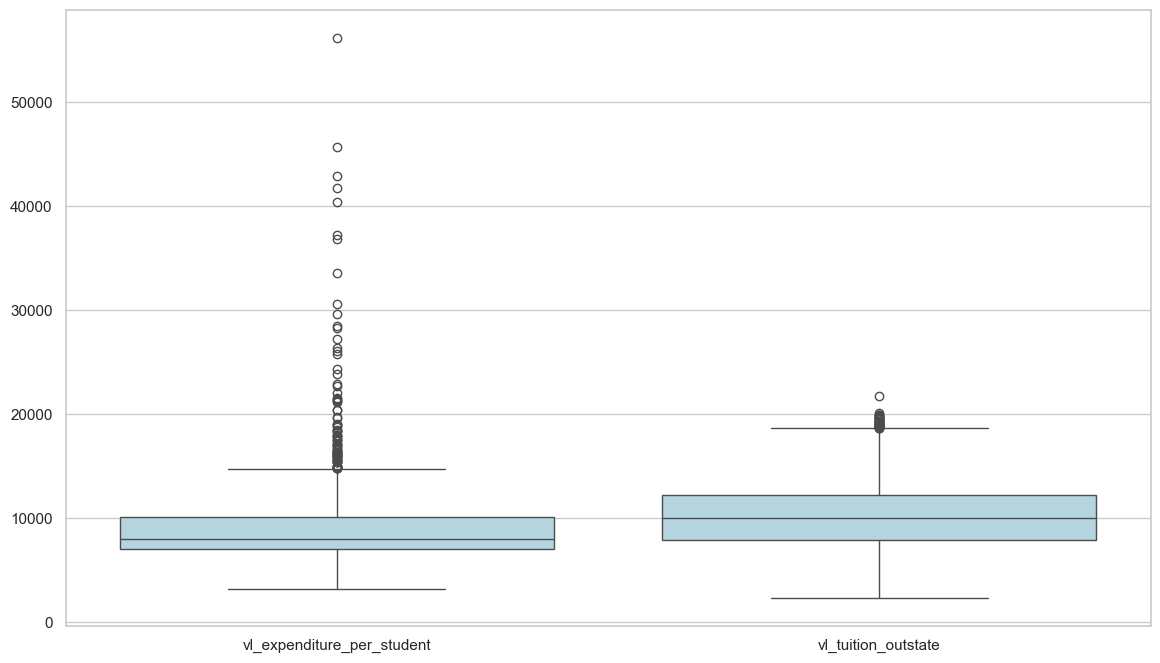

In [22]:
# AVALIAR
plt.figure()
sns.boxplot(data=df[colunas_outliers], color='lightblue')

<Axes: >

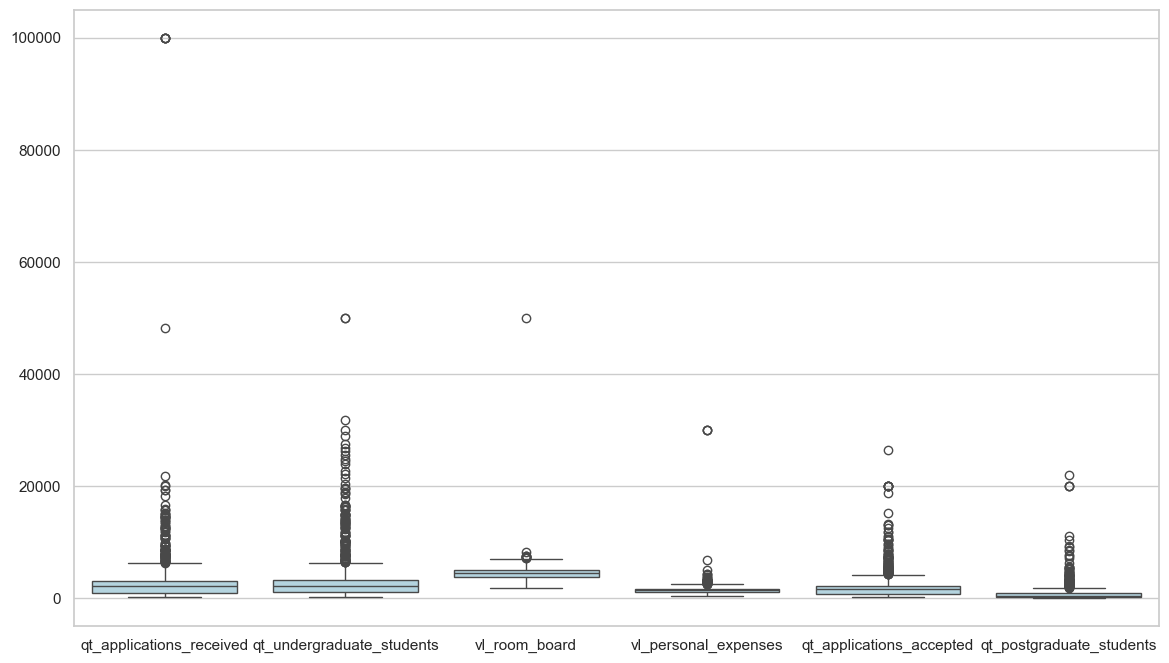

In [23]:
colunas_outliers = ['qt_applications_received','qt_undergraduate_students','vl_room_board','vl_personal_expenses','qt_applications_accepted','qt_postgraduate_students']

plt.figure()
sns.boxplot(data=df[colunas_outliers], color='lightblue')

In [24]:
for col in colunas_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    print(f"Coluna: {col}")
    display(df[df[col] > upper].sort_values(by=col,ascending=False).head(10))

Coluna: qt_applications_received


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
695,Julius Caesar Academy,False,100000.0,NaN,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,NaN,8000.0,NaN
821,Che Guevara Institute,True,100000.0,1500.0,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,NaN,15.0,20.0,8000.0,60.0
697,Leonardo da Vinci Institute,True,100000.0,1500.0,500.0,NaN,40.0,2000.0,300.0,NaN,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
663,Galileo Center for Studies,True,100000.0,NaN,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
423,Abraham Lincoln College,True,100000.0,1500.0,500.0,NaN,40.0,NaN,300.0,10000.0,5000.0,NaN,1500.0,60.0,NaN,15.0,20.0,8000.0,NaN
895,Rutgers at New Brunswick,False,48094.0,26330.0,4520.0,36.0,79.0,21401.0,3712.0,7410.0,4748.0,690.0,2009.0,90.0,95.0,19.5,19.0,10474.0,77.0
235,Purdue University at West Lafayette,False,21804.0,18744.0,5874.0,29.0,60.0,26213.0,4065.0,9556.0,3990.0,570.0,1060.0,86.0,86.0,18.2,15.0,8604.0,67.0
753,Boston University,True,20192.0,13007.0,3810.0,45.0,80.0,14971.0,3113.0,18420.0,6810.0,475.0,1025.0,80.0,81.0,11.9,16.0,16836.0,72.0
920,University of California at Berkeley,False,19873.0,8252.0,3215.0,95.0,100.0,19532.0,2061.0,11648.0,6246.0,636.0,1933.0,93.0,97.0,15.8,10.0,13919.0,78.0
538,Pennsylvania State Univ. Main Campus,False,19315.0,10344.0,3450.0,48.0,93.0,28938.0,2025.0,10645.0,4060.0,512.0,2394.0,77.0,96.0,18.1,19.0,8992.0,63.0


Coluna: qt_undergraduate_students


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
362,Marie Curie Institute,True,NaN,1500.0,10000.0,20.0,40.0,50000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
268,Martin Luther King Jr. School of Arts,True,2000.0,1500.0,500.0,NaN,40.0,50000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
590,Texas A&M Univ. at College Station,False,14474.0,10519.0,6392.0,49.0,85.0,31643.0,2798.0,5130.0,3412.0,600.0,2144.0,89.0,91.0,23.1,29.0,8471.0,69.0
283,University of Texas at Austin,False,14752.0,9572.0,5329.0,48.0,85.0,30017.0,5189.0,5130.0,3309.0,650.0,3140.0,91.0,99.0,19.7,11.0,7837.0,65.0
538,Pennsylvania State Univ. Main Campus,False,19315.0,10344.0,3450.0,48.0,93.0,28938.0,2025.0,10645.0,4060.0,512.0,2394.0,77.0,96.0,18.1,19.0,8992.0,63.0
349,Brigham Young University at Provo,True,7365.0,5402.0,4615.0,48.0,82.0,27378.0,1253.0,2340.0,3580.0,860.0,1220.0,76.0,76.0,20.5,40.0,7916.0,33.0
818,Michigan State University,False,18114.0,15096.0,6180.0,23.0,57.0,26640.0,4120.0,10658.0,3734.0,504.0,600.0,93.0,95.0,14.0,9.0,10520.0,71.0
235,Purdue University at West Lafayette,False,21804.0,18744.0,5874.0,29.0,60.0,26213.0,4065.0,9556.0,3990.0,570.0,1060.0,86.0,86.0,18.2,15.0,8604.0,67.0
12,University of Illinois - Urbana,False,14939.0,11652.0,5705.0,52.0,88.0,25422.0,911.0,7560.0,4574.0,500.0,1982.0,87.0,90.0,17.4,13.0,8559.0,81.0
853,Indiana University at Bloomington,False,16587.0,13243.0,5873.0,25.0,72.0,24763.0,2717.0,9766.0,3990.0,600.0,2000.0,77.0,88.0,21.3,24.0,8686.0,68.0


Coluna: vl_room_board


...

,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
143,Emily Dickinson Academy,False,2000.0,1500.0,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,NaN,30000.0,60.0,60.0,15.0,20.0,8000.0,60.0
762,Joan of Arc Center for Studies,False,NaN,1500.0,500.0,20.0,40.0,NaN,300.0,NaN,5000.0,600.0,30000.0,60.0,60.0,15.0,20.0,NaN,60.0
858,Leonardo da Vinci Academy,True,2000.0,NaN,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,30000.0,60.0,60.0,NaN,20.0,8000.0,NaN
655,Saint Louis University,True,3294.0,2855.0,956.0,44.0,67.0,4576.0,1140.0,11690.0,4730.0,800.0,6800.0,84.0,94.0,4.6,19.0,18367.0,67.0
161,MidAmerica Nazarene College,True,331.0,331.0,225.0,15.0,36.0,1100.0,166.0,6840.0,3720.0,1100.0,4913.0,33.0,33.0,15.4,20.0,5524.0,49.0
67,University of Missouri at Saint Louis,False,1618.0,1141.0,479.0,18.0,54.0,4793.0,4552.0,7246.0,3964.0,500.0,4288.0,71.0,73.0,13.4,15.0,6433.0,48.0
248,Lindenwood College,True,810.0,484.0,356.0,6.0,33.0,2155.0,191.0,9200.0,4800.0,1000.0,4200.0,65.0,85.0,24.1,9.0,3480.0,100.0
191,Oglethorpe University,True,792.0,649.0,186.0,56.0,87.0,769.0,377.0,12900.0,4340.0,600.0,4110.0,91.0,95.0,13.1,27.0,8568.0,67.0
69,William Woods University,True,469.0,435.0,227.0,17.0,39.0,851.0,120.0,10535.0,4365.0,550.0,3700.0,39.0,66.0,12.9,16.0,7438.0,52.0
361,Virginia Commonwealth University,False,4963.0,3497.0,1567.0,18.0,45.0,10262.0,5065.0,10217.0,4182.0,500.0,3630.0,81.0,87.0,8.7,11.0,11183.0,45.0


Coluna: qt_applications_accepted


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
895,Rutgers at New Brunswick,False,48094.0,26330.0,4520.0,36.0,79.0,21401.0,3712.0,7410.0,4748.0,690.0,2009.0,90.0,95.0,19.5,19.0,10474.0,77.0
331,Jane Austen Institute,True,2000.0,20000.0,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,NaN,1500.0,60.0,NaN,15.0,20.0,8000.0,60.0
574,Socrates School of Arts,False,2000.0,20000.0,500.0,20.0,40.0,2000.0,300.0,NaN,5000.0,600.0,NaN,60.0,60.0,NaN,20.0,8000.0,60.0
835,Hypatia Academy,True,2000.0,20000.0,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
597,Rosa Parks School of Arts,True,2000.0,20000.0,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,NaN,20.0,8000.0,60.0
860,Simón Bolívar Center for Studies,True,2000.0,20000.0,500.0,20.0,40.0,2000.0,300.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
813,Albert Einstein Center for Studies,True,2000.0,20000.0,500.0,20.0,NaN,2000.0,300.0,NaN,5000.0,600.0,1500.0,NaN,60.0,15.0,20.0,NaN,60.0
235,Purdue University at West Lafayette,False,21804.0,18744.0,5874.0,29.0,60.0,26213.0,4065.0,9556.0,3990.0,570.0,1060.0,86.0,86.0,18.2,15.0,8604.0,67.0
818,Michigan State University,False,18114.0,15096.0,6180.0,23.0,57.0,26640.0,4120.0,10658.0,3734.0,504.0,600.0,93.0,95.0,14.0,9.0,10520.0,71.0
853,Indiana University at Bloomington,False,16587.0,13243.0,5873.0,25.0,72.0,24763.0,2717.0,9766.0,3990.0,600.0,2000.0,77.0,88.0,21.3,24.0,8686.0,68.0


Coluna: qt_postgraduate_students


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
889,University of Minnesota Twin Cities,False,11054.0,6397.0,3524.0,26.0,55.0,16502.0,21836.0,8949.0,3744.0,714.0,2910.0,88.0,90.0,12.2,37.0,16122.0,45.0
184,Emily Dickinson Center for Studies,False,2000.0,1500.0,500.0,20.0,40.0,2000.0,20000.0,10000.0,5000.0,600.0,1500.0,60.0,NaN,15.0,20.0,8000.0,60.0
606,Julius Caesar College,True,2000.0,1500.0,500.0,20.0,40.0,2000.0,20000.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0
970,Nikola Tesla Academy,True,2000.0,1500.0,500.0,20.0,40.0,2000.0,20000.0,10000.0,5000.0,600.0,1500.0,60.0,NaN,15.0,20.0,8000.0,60.0
517,University of South Florida,False,7589.0,4676.0,1876.0,29.0,63.0,14770.0,10962.0,6760.0,3776.0,500.0,2180.0,84.0,89.0,17.0,7.0,11020.0,47.0
453,Northeastern University,True,11901.0,8492.0,2517.0,16.0,42.0,11160.0,10221.0,13380.0,7425.0,600.0,1750.0,73.0,82.0,12.9,17.0,9563.0,46.0
390,Florida International University,False,3306.0,2079.0,1071.0,42.0,89.0,10208.0,9310.0,6597.0,2494.0,800.0,3028.0,81.0,96.0,13.9,20.0,6722.0,66.0
104,Georgia State University,False,3793.0,2341.0,1238.0,9.0,24.0,7732.0,9054.0,6744.0,2655.0,720.0,3450.0,87.0,89.0,19.0,10.0,7762.0,34.0
439,University of Texas at Arlington,False,3281.0,2559.0,1448.0,19.0,43.0,10975.0,8431.0,4422.0,2780.0,500.0,2850.0,73.0,73.0,21.0,4.0,4696.0,29.0
110,University of Utah,False,5095.0,4491.0,2400.0,27.0,53.0,13894.0,8374.0,6857.0,3975.0,858.0,3093.0,89.0,93.0,12.8,9.0,9275.0,37.0


In [25]:
# Análise em colunas correlacionadas

filtro = df[(df['qt_students_enrolled'] == 500) & 
        (
          (df['qt_applications_accepted'] == 1500) | (df['qt_applications_accepted'].isna())
        )]

filtro_mediana = filtro['qt_applications_received'].median()

print(f"Valor mais comum no filtro: {filtro_mediana}")

Valor mais comum no filtro: 2000.0


In [26]:
# Uma vez que colunas estão correlacionadas podemos fazer correção por regra lógica

df.loc[(df['qt_applications_received'] == 100000), 'qt_applications_received'] = 2000

In [27]:
# Aproveitamos para corrigir também os NaN de 'qt_applications_accepted'

filtro = df[(df['qt_applications_received'] == 2000) & (df['qt_students_enrolled'] == 500) & (df['qt_applications_accepted'].notna())]

filtro_mediana = filtro['qt_applications_accepted'].median()

print(f"Valor mais comum no filtro: {filtro_mediana}")

Valor mais comum no filtro: 1500.0


In [28]:
df.loc[(df['qt_applications_received'] == 20000) & (df['qt_students_enrolled'] == 500) & (df['qt_applications_accepted'].isna()), 'qt_applications_accepted'] = 1500

In [29]:
#remover outliers impossíveis
df = df[
        ((df['qt_undergraduate_students'] < 50000) | (df['qt_undergraduate_students'].isnull())) &
        ((df['vl_room_board'] < 50000) | (df['vl_room_board'].isnull())) &
        ((df['vl_personal_expenses'] < 30000) | (df['vl_personal_expenses'].isnull()))
    ]

print(f"N. linhas após limpeza: {df.shape[0]}")
print(f"Percentual total de linhas removidas: {(1 - df.shape[0] / linhas_originais):.0%}")

N. linhas após limpeza: 946
Percentual total de linhas removidas: 3%


<Axes: >

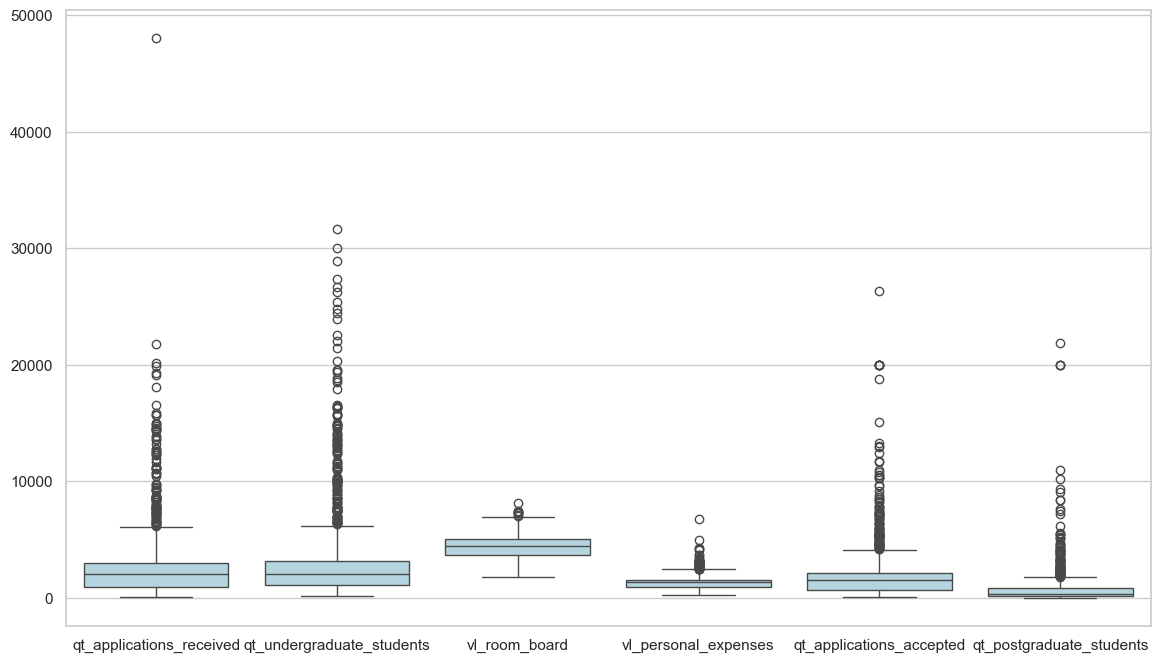

In [30]:
# AVALIAR
colunas_outliers = ['qt_applications_received','qt_undergraduate_students','vl_room_board','vl_personal_expenses','qt_applications_accepted','qt_postgraduate_students']

plt.figure()
sns.boxplot(data=df[colunas_outliers], color='lightblue')

In [34]:
# máscara de inconsistência
mask_inconsistente = (
    (df["qt_applications_received"] < df["qt_applications_accepted"]) |
    (df["qt_applications_accepted"] < df["qt_students_enrolled"])
)

df_inconsistentes = df[mask_inconsistente]

print(f"Percentual de linhas inconsistentes: {(df_inconsistentes.shape[0] / df.shape[0]):.2%}")

display(df_inconsistentes[colunas_graduate])

Percentual de linhas inconsistentes: 0.00%


,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_undergraduate_students


In [32]:
#Correcao
df.loc[(df['qt_applications_received'] == 2000) & (df['qt_applications_accepted'] == 20000) & (df['qt_students_enrolled'] == 500), 'qt_applications_accepted'] = 2000
df.loc[(df['qt_applications_received'] == 2000) & (df['qt_applications_accepted'] == 1500) & (df['qt_students_enrolled'] == 10000), 'qt_students_enrolled'] = 1000

In [36]:
# máscara de inconsistência
mask_inconsistente = (df["qt_top_10_percent"] > df["qt_top_25_percent"])

df_inconsistentes = df[mask_inconsistente]

print(f"Percentual de linhas inconsistentes: {(df_inconsistentes.shape[0] / df.shape[0]):.2%}")

display(df_inconsistentes)

Percentual de linhas inconsistentes: 0.00%


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate


In [35]:
#Correção por regra lógica

df.loc[(df['qt_top_10_percent'] > 0) & (df['qt_top_10_percent'] < 100) & (df['qt_top_10_percent'] > df['qt_top_25_percent']), 'qt_top_25_percent'] = df['qt_top_10_percent']
df.loc[(df['qt_top_25_percent'] > 0) & (df['qt_top_25_percent'] < 100) & (df['qt_top_10_percent'] > df['qt_top_25_percent']), 'qt_top_10_percent'] = df['qt_top_25_percent']

In [39]:
# máscara de inconsistência
mask_inconsistente = (df["pc_faculty_with_phd"] > df["pc_faculty_with_terminal_degree"])

df_inconsistentes = df[mask_inconsistente]

print(f"Percentual de linhas inconsistentes: {(df_inconsistentes.shape[0] / df.shape[0]):.2%}")

display(df_inconsistentes)

Percentual de linhas inconsistentes: 0.00%


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate


In [38]:
#Correção por regra lógica

df.loc[(df['pc_faculty_with_phd'] > 0) & (df['pc_faculty_with_phd'] < 100) & (df['pc_faculty_with_phd'] > df['pc_faculty_with_terminal_degree']), 'pc_faculty_with_terminal_degree'] = df['pc_faculty_with_phd']

df.loc[(df['pc_faculty_with_terminal_degree'] > 0) & (df['pc_faculty_with_terminal_degree'] < 100) & (df['pc_faculty_with_phd'] > df['pc_faculty_with_terminal_degree']), 'pc_faculty_with_phd'] = df['pc_faculty_with_terminal_degree']

In [40]:

## AVALIAR IMPUTACAO POR CORRELAÇÃO COM OUTRAS COLUNAS

print("\n--- Aplicação de Imputação ---")

# Estratégia: Como existem outliers, vamos usar a MEDIANA em vez da Média.
imputer = SimpleImputer(strategy='median')

# Nota: O fit_transform retorna um array numpy, precisamos converter de volta para DataFrame
# Aplicamos apenas na coluna 'age' que tinha falhas
df[colunas_numericas] = imputer.fit_transform(df[colunas_numericas])

print("Nulos após imputação:")
print(df.isnull().sum())


--- Aplicação de Imputação ---
Nulos após imputação:
nm_college                         0
bl_private                         0
qt_applications_received           0
qt_applications_accepted           0
qt_students_enrolled               0
qt_top_10_percent                  0
qt_top_25_percent                  0
qt_undergraduate_students          0
qt_postgraduate_students           0
vl_tuition_outstate                0
vl_room_board                      0
vl_books_cost                      0
vl_personal_expenses               0
pc_faculty_with_phd                0
pc_faculty_with_terminal_degree    0
vl_student_faculty_ratio           0
pc_alumni_donors                   0
vl_expenditure_per_student         0
pc_graduation_rate                 0
dtype: int64


In [41]:
# Aplicar transformação logarítmica para suavizar a curva
df_transf = np.log1p(df[colunas_numericas])

<Axes: ylabel='Count'>

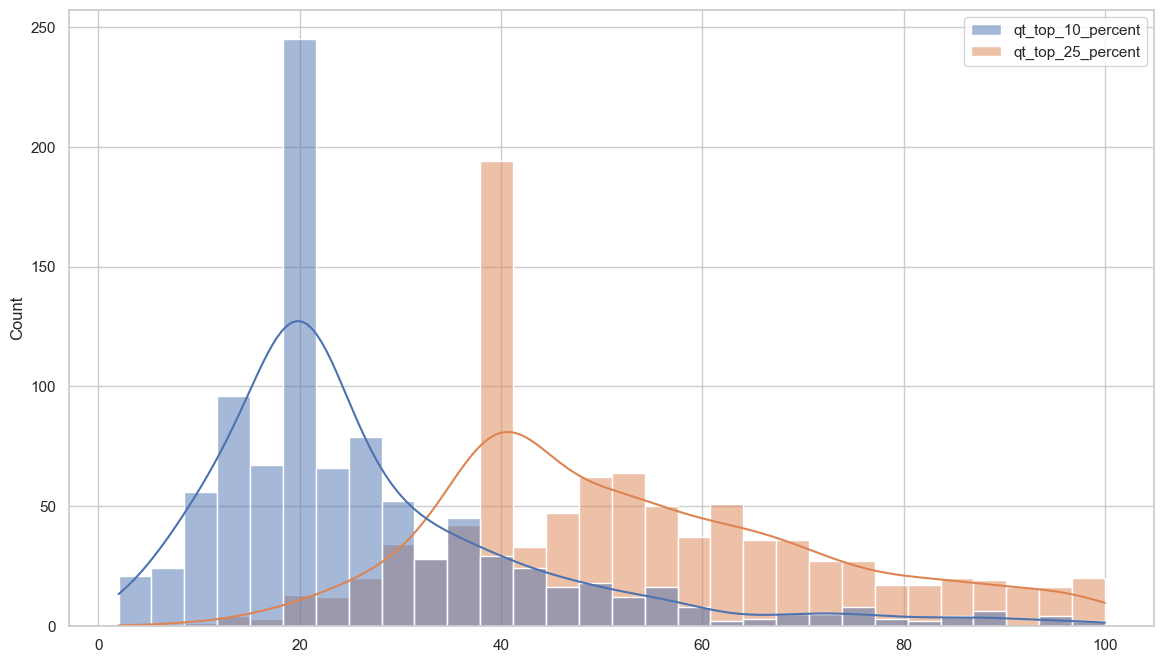

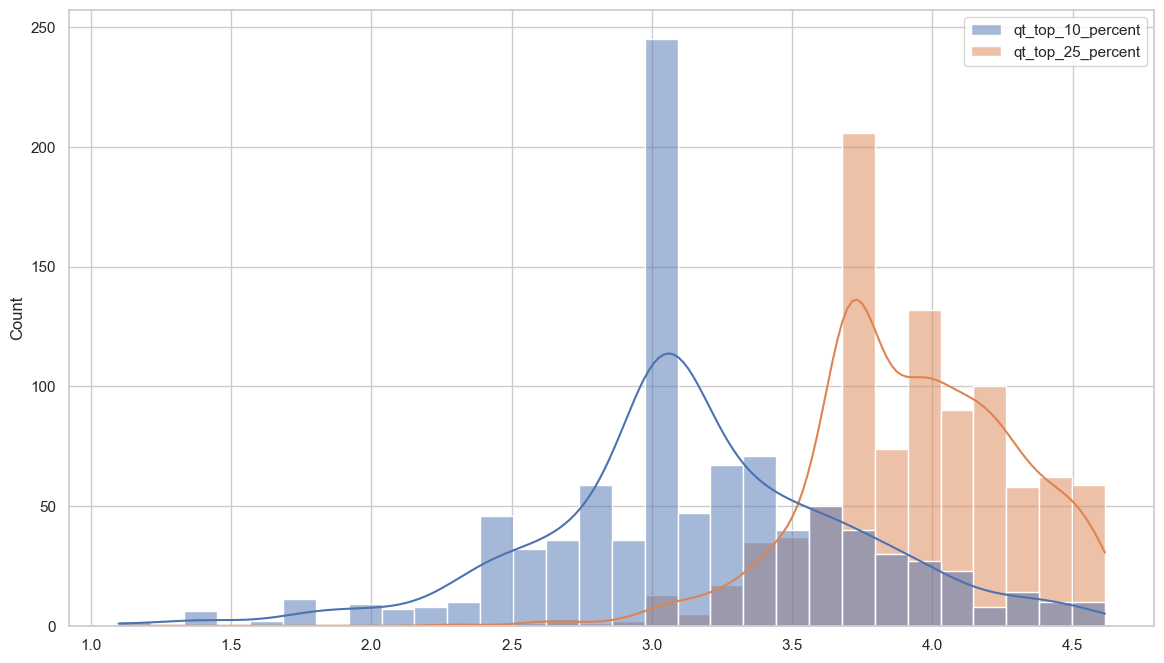

In [45]:
plt.figure()
sns.histplot(df[colunas_top_perc], kde=True, bins=30, color='blue')

plt.figure()
sns.histplot(df_transf[colunas_top_perc], kde=True, bins=30, color='blue')

In [46]:
df_scaled = df_transf.copy();

scaler = RobustScaler()
df_scaled[colunas_numericas] = scaler.fit_transform(df_transf[colunas_numericas])

<Axes: ylabel='Count'>

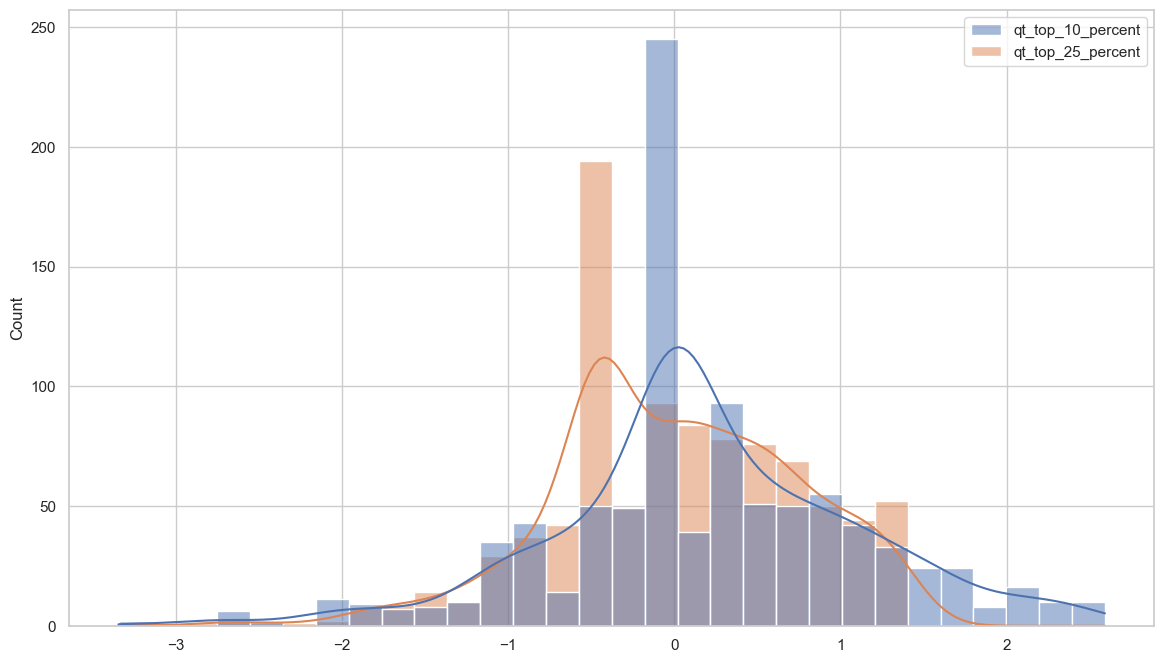

In [48]:
plt.figure()
sns.histplot(df_scaled[colunas_top_perc], kde=True, bins=30, color='blue')

In [ ]:
# Split Treino/Teste (Fundamental para validar a seleção)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Treino
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Importâncias
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Ordenar decrescente

print("--- EMBEDDED METHOD (Random Forest) ---")
print("Top 5 Genes mais importantes:")
for i in range(5):
    print(f"{gene_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Gráfico
plt.figure(figsize=(10, 4))
plt.title("Feature Importance (Random Forest) - Top 30")
plt.bar(range(30), importances[indices[:30]], align="center")
plt.xticks(range(30), [gene_names[i] for i in indices[:30]], rotation=90)
plt.show()

## 4) EDA: distribuições e outliers (mínimo: 3 a 6 gráficos úteis)

In [ ]:
# Escolha algumas colunas numéricas para plotar

colunas_para_plotar = ['pc_graduation_rate', 'qt_top_10_percent', 'qt_top_25_percent', 'pc_alumni_donors', 'pc_faculty_with_phd', 'pc_faculty_with_terminal_degree']

# Exemplo: histogramas para algumas colunas

plt.figure()
sns.histplot(df[colunas_para_plotar], kde=True, bins=30, color='blue')

plt.figure()
sns.boxplot(data=df[colunas_para_plotar], color='lightblue')

In [ ]:
coluna_outliers = 'qt_top_10_percent'

Q1 = df[coluna_outliers].quantile(0.25)
Q3 = df[coluna_outliers].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df[coluna_outliers] < lower) |
    (df[coluna_outliers] > upper)
]

print(outliers[coluna_outliers])

## 5) Pergunta dirigida (obrigatória):

In [ ]:
# ============================================================
#    Quais variáveis parecem influenciar pc_graduation_rate?
# ============================================================

target_grad = "pc_graduation_rate"

# Correlação simples (apenas numéricas)

corr_pearson = df.corr(method='pearson', numeric_only=True)
corr_spearman = df.corr(method='spearman', numeric_only=True)

# Gráfico: top correlações (ajuste como quiser)

plt.figure()
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Escreva aqui 3-6 linhas com a sua interpretação e hipóteses:
# - Quais variáveis parecem mais relevantes?
# - Existe alguma relação inesperada?
# - Há risco de correlação espúria?


## 6) Pergunta criada pelo grupo/estudante (obrigatória)

1) Escreva aqui a sua pergunta:
Ex.: "Instituições com maior expenditure_per_student têm maior graduation_rate?"

Ex.: "O tipo (privada/pública) altera a relação entre tuition e graduation_rate?"

In [ ]:
# 2) Faça uma análise simples para responder:
#    - gráfico(s)
#    - uma medida numérica (correlação, comparação de médias, etc.)
#    - uma conclusão curta


## 7) Escolha 1 desafio de Machine Learning

In [ ]:
# ============================================================
#    (A) Classificação OU (B) Regressão OU (C) Clustering
# ============================================================

# Marque aqui qual desafio escolheu:
CHALLENGE = "A"  # "A" = Classificação | "B" = Regressão | "C" = Clustering


In [ ]:
# ============================================================
# 7A) CLASSIFICAÇÃO — privada vs pública (bl_private)
# ============================================================


    # 7) Interpretação (escreva aqui)
    # - O resultado é bom o suficiente? Por quê?
    # - Onde o modelo erra mais (falsos positivos/negativos)?
    # - Quais variáveis parecem mais importantes (se usar árvores/forest)?


In [ ]:
# ============================================================
# 7B) REGRESSÃO — estimar vl_tuition_outstate
# ============================================================

    # 7) Interpretação (escreva aqui)
    # - O erro está alto ou baixo? Como você interpreta em euros?
    # - Há vieses (subestima para valores altos, etc.)?
    # - O que faria para melhorar (mais dados, features, outro modelo)?


In [ ]:
# ============================================================
# 7C) CLUSTERING — segmentação de instituições
# ============================================================


    # 7) Interpretação (escreva aqui)
    # - Que perfil cada cluster parece ter?
    # - Que variáveis mais diferenciam os grupos?
    # - Que ação de gestão você recomendaria para cada grupo?


## 8) Conclusões e reflexão final (obrigatório)

In [ ]:
# Responda de forma direta:
# 1) O que você descobriu no EDA que mudou sua visão do problema?
# 2) Quais variáveis parecem mais ligadas ao sucesso académico (graduation_rate) e por quê?
# 3) O desafio de ML escolhido ajudou a responder o quê?
# 4) Limitações (dados, suposições, simplificações) e próximos passos realistas.